## 05 pgvector scaling evaluation

### Purpose

This notebook evaluates the **implementation-side performance** of the final selected curriculum-overlap detection configuration in a **PostgreSQL + pgvector** environment.

It addresses the second thesis research question:

**How does performance scale with corpus size in a pgvector implementation?**

### Scope of this notebook

This notebook does **not** perform a new semantic benchmark.

That work was already completed earlier:

- Notebook 03 benchmarked embedding models and similarity metrics
- Notebook 04 selected the final thresholded operating point
- Notebook 05 produced the final reusable artifacts

Notebook 06 focuses only on **pgvector retrieval performance**.

### What this notebook evaluates

This notebook evaluates two related implementation questions:

1. **Operational evaluation at the real 50-course proof-of-concept scale**
2. **Scaling behaviour under moderate corpus growth from 50 rows to 150 rows**

Here, the 50-row benchmark corresponds to the real 50-course corpus, while the larger benchmark sizes are controlled row-count expansions used only for scaling analysis.

### Main outputs

This notebook will:

1. load the final selected configuration and final embeddings
2. prepare benchmark corpora for pgvector evaluation
3. insert benchmark rows into PostgreSQL
4. measure pgvector query latency across corpus sizes
5. summarize the results for thesis reporting

In [41]:
# Cell 01 - Import libraries and define notebook paths

from pathlib import Path
import os
import time
import math
from typing import Dict

import numpy as np
import pandas as pd

try:
    import psycopg
    PSYCOPG_AVAILABLE = True
except Exception:
    PSYCOPG_AVAILABLE = False

try:
    from dotenv import load_dotenv
    DOTENV_AVAILABLE = True
except Exception:
    DOTENV_AVAILABLE = False

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = PROJECT_ROOT / "reports" / "tables"
THRESHOLD_DIR = REPORTS_DIR / "thresholds"
OUTPUT_DIR = REPORTS_DIR / "pgvector_scaling"

FINAL_EMBEDDINGS_PATH = DATA_DIR / "final_embeddings.parquet"
FINAL_RECOMMENDATION_PATH = THRESHOLD_DIR / "final_threshold_recommendation.csv"
ENV_PATH = PROJECT_ROOT / ".env"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Final embeddings path:", FINAL_EMBEDDINGS_PATH)
print("Final recommendation path:", FINAL_RECOMMENDATION_PATH)
print("Output directory:", OUTPUT_DIR)
print("psycopg available:", PSYCOPG_AVAILABLE)
print("dotenv available:", DOTENV_AVAILABLE)

Project root: C:\Users\user\Documents\thesis
Final embeddings path: C:\Users\user\Documents\thesis\data\final_embeddings.parquet
Final recommendation path: C:\Users\user\Documents\thesis\reports\tables\thresholds\final_threshold_recommendation.csv
Output directory: C:\Users\user\Documents\thesis\reports\tables\pgvector_scaling
psycopg available: True
dotenv available: True


In [42]:
# Cell 02 - Load environment variables for PostgreSQL and pgvector

if DOTENV_AVAILABLE and ENV_PATH.exists():
    load_dotenv(ENV_PATH, override=True)

DATABASE_URL = os.getenv("DATABASE_URL", "").strip()
PGVECTOR_TABLE = os.getenv("PGVECTOR_TABLE", "").strip()
USE_PGVECTOR = os.getenv("USE_PGVECTOR", "").strip().lower()

print("Environment file exists:", ENV_PATH.exists())
print("DATABASE_URL loaded:", "Yes" if DATABASE_URL else "No")
print("PGVECTOR_TABLE:", PGVECTOR_TABLE if PGVECTOR_TABLE else "(missing)")
print("USE_PGVECTOR:", USE_PGVECTOR if USE_PGVECTOR else "(missing)")

Environment file exists: True
DATABASE_URL loaded: Yes
PGVECTOR_TABLE: course_embeddings_benchmark
USE_PGVECTOR: true


In [43]:
# Cell 03 - Load final artifacts from previous notebooks

if not FINAL_EMBEDDINGS_PATH.exists():
    raise FileNotFoundError(f"Missing file: {FINAL_EMBEDDINGS_PATH}")

if not FINAL_RECOMMENDATION_PATH.exists():
    raise FileNotFoundError(f"Missing file: {FINAL_RECOMMENDATION_PATH}")

final_embeddings_df = pd.read_parquet(FINAL_EMBEDDINGS_PATH).copy()
final_recommendation_df = pd.read_csv(FINAL_RECOMMENDATION_PATH).copy()

print("final_embeddings_df shape:", final_embeddings_df.shape)
print("final_recommendation_df shape:", final_recommendation_df.shape)

display(final_recommendation_df)
display(final_embeddings_df.head(3))

final_embeddings_df shape: (50, 14)
final_recommendation_df shape: (2, 17)


,recommendation_type,model_name,text_variant,similarity_metric,selection_rule,locked_threshold,shortlist_rank,average_precision,roc_auc,dev_f1,dev_f05,test_f1,test_f05,test_precision,test_recall,dev_predicted_positive_count,test_predicted_positive_count
0,primary_recommendation,openai_text-embedding-3-large,enriched,cosine,max_f1,0.673784,1,0.939595,0.994870,0.894737,0.923913,0.769231,0.892857,1.0,0.625,18,5
1,conservative_alternative,openai_text-embedding-3-large,main,cosine,max_f1,0.659979,2,0.927445,0.995913,0.871795,0.885417,0.769231,0.892857,1.0,0.625,19,5


,course_unit_code,course_name,final_embedding_text,final_model_name,final_openai_model_id,final_text_variant,final_similarity_metric,final_selection_rule,final_locked_threshold,embedding_dim,embedding_generation_seconds,raw_embedding_norm,normalized_embedding_norm,embedding_vector
0,TT00CD70,Data Networks,Data Networks\nYou learn the structure and pro...,openai_text-embedding-3-large,text-embedding-3-large,enriched,cosine,max_f1,0.673784,3072,3.002128,1.000048,1.0,"[-0.02810533344745636, 0.020735694095492363, -..."
1,TT00CD71,Linux Basics,"Linux Basics\nAfter completing the course, you...",openai_text-embedding-3-large,text-embedding-3-large,enriched,cosine,max_f1,0.673784,3072,3.002128,0.999847,1.0,"[-0.013971555046737194, 0.03848854452371597, -..."
2,TT00CD72,Servers and containers,Servers and containers\nYou understand the fun...,openai_text-embedding-3-large,text-embedding-3-large,enriched,cosine,max_f1,0.673784,3072,3.002128,0.999609,1.0,"[-0.028056597337126732, 0.029399896040558815, ..."


In [44]:
# Cell 04 - Validate the final selected configuration

required_recommendation_cols = [
    "recommendation_type",
    "model_name",
    "text_variant",
    "similarity_metric",
    "selection_rule",
    "locked_threshold",
]

required_embedding_cols = [
    "course_unit_code",
    "course_name",
    "final_embedding_text",
    "final_model_name",
    "final_text_variant",
    "final_similarity_metric",
    "final_selection_rule",
    "final_locked_threshold",
    "embedding_vector",
    "embedding_dim",
]

missing_recommendation_cols = [c for c in required_recommendation_cols if c not in final_recommendation_df.columns]
missing_embedding_cols = [c for c in required_embedding_cols if c not in final_embeddings_df.columns]

if missing_recommendation_cols:
    raise ValueError(f"final_threshold_recommendation.csv is missing columns: {missing_recommendation_cols}")

if missing_embedding_cols:
    raise ValueError(f"final_embeddings.parquet is missing columns: {missing_embedding_cols}")

primary_recommendation_df = final_recommendation_df[
    final_recommendation_df["recommendation_type"] == "primary_recommendation"
].copy()

if primary_recommendation_df.empty:
    raise ValueError("Could not find 'primary_recommendation' row in final_threshold_recommendation.csv")

if len(primary_recommendation_df) != 1:
    raise ValueError("Expected exactly one 'primary_recommendation' row")

primary_row = primary_recommendation_df.iloc[0]

FINAL_MODEL_NAME = str(primary_row["model_name"])
FINAL_TEXT_VARIANT = str(primary_row["text_variant"])
FINAL_SIMILARITY_METRIC = str(primary_row["similarity_metric"])
FINAL_SELECTION_RULE = str(primary_row["selection_rule"])
FINAL_LOCKED_THRESHOLD = float(primary_row["locked_threshold"])

artifact_model_names = set(final_embeddings_df["final_model_name"].astype(str).unique())
artifact_text_variants = set(final_embeddings_df["final_text_variant"].astype(str).unique())
artifact_similarity_metrics = set(final_embeddings_df["final_similarity_metric"].astype(str).unique())
artifact_selection_rules = set(final_embeddings_df["final_selection_rule"].astype(str).unique())

if artifact_model_names != {FINAL_MODEL_NAME}:
    raise ValueError(f"Model mismatch: {sorted(artifact_model_names)} vs {FINAL_MODEL_NAME}")

if artifact_text_variants != {FINAL_TEXT_VARIANT}:
    raise ValueError(f"Text variant mismatch: {sorted(artifact_text_variants)} vs {FINAL_TEXT_VARIANT}")

if artifact_similarity_metrics != {FINAL_SIMILARITY_METRIC}:
    raise ValueError(f"Similarity metric mismatch: {sorted(artifact_similarity_metrics)} vs {FINAL_SIMILARITY_METRIC}")

if artifact_selection_rules != {FINAL_SELECTION_RULE}:
    raise ValueError(f"Selection rule mismatch: {sorted(artifact_selection_rules)} vs {FINAL_SELECTION_RULE}")

print("Final selected configuration:")
print("  Model           :", FINAL_MODEL_NAME)
print("  Text variant    :", FINAL_TEXT_VARIANT)
print("  Similarity      :", FINAL_SIMILARITY_METRIC)
print("  Selection rule  :", FINAL_SELECTION_RULE)
print("  Locked threshold:", round(FINAL_LOCKED_THRESHOLD, 10))
print()
print("Artifact consistency check: PASSED")

Final selected configuration:
  Model           : openai_text-embedding-3-large
  Text variant    : enriched
  Similarity      : cosine
  Selection rule  : max_f1
  Locked threshold: 0.6737841964

Artifact consistency check: PASSED


### Benchmark design

The benchmark has two roles.

**Role 1: operational evaluation at 50 courses**  
The real 50-course corpus is the main proof-of-concept operating scale, so it is treated as the primary operational benchmark.

**Role 2: scaling analysis beyond 50 courses**  
To study how pgvector behaves as row count grows, additional benchmark corpora are created at:

- 75 rows
- 100 rows
- 125 rows
- 150 rows

These larger corpora are used only for **performance scaling analysis**.

They are **not** used for:

- semantic quality evaluation
- threshold optimization
- overlap-label analysis

In [45]:
# Cell 05 - Prepare the real 50-course base corpus

base_corpus_df = final_embeddings_df[
    [
        "course_unit_code",
        "course_name",
        "final_embedding_text",
        "final_model_name",
        "final_text_variant",
        "final_similarity_metric",
        "final_selection_rule",
        "final_locked_threshold",
        "embedding_vector",
        "embedding_dim",
    ]
].copy()

base_corpus_df["benchmark_source"] = "real_base_corpus"
base_corpus_df["benchmark_replica_index"] = 0
base_corpus_df["benchmark_course_id"] = base_corpus_df["course_unit_code"].astype(str)

base_corpus_df = base_corpus_df.sort_values("course_unit_code").reset_index(drop=True)

embedding_dims = sorted(base_corpus_df["embedding_dim"].dropna().unique().tolist())
if len(embedding_dims) != 1:
    raise ValueError(f"Expected exactly one embedding dimension, got {embedding_dims}")

print("base_corpus_df shape:", base_corpus_df.shape)
print("Unique course codes:", base_corpus_df["course_unit_code"].nunique())
print("Embedding dimensions:", embedding_dims)

display(base_corpus_df.head(3))

base_corpus_df shape: (50, 13)
Unique course codes: 50
Embedding dimensions: [3072]


,course_unit_code,course_name,final_embedding_text,final_model_name,final_text_variant,final_similarity_metric,final_selection_rule,final_locked_threshold,embedding_vector,embedding_dim,benchmark_source,benchmark_replica_index,benchmark_course_id
0,TE00BR86,Back-End Development,Back-End Development\nAfter completing the cou...,openai_text-embedding-3-large,enriched,cosine,max_f1,0.673784,"[-0.004093149211257696, 0.025375235825777054, ...",3072,real_base_corpus,0,TE00BR86
1,TE00CN56,Internet Networks and Security,Internet Networks and Security\nAfter completi...,openai_text-embedding-3-large,enriched,cosine,max_f1,0.673784,"[-0.025639748200774193, 0.04221401363611221, -...",3072,real_base_corpus,0,TE00CN56
2,TE00CS88,Introduction to Programming,Introduction to Programming\nAfter completing ...,openai_text-embedding-3-large,enriched,cosine,max_f1,0.673784,"[-0.008813620544970036, 0.012995321303606033, ...",3072,real_base_corpus,0,TE00CS88


In [46]:
# Cell 06 - Build benchmark corpora for scaling analysis

TARGET_CORPUS_SIZES = [50, 75, 100, 125, 150]

def build_benchmark_corpus(base_df: pd.DataFrame, target_size: int) -> pd.DataFrame:
    if target_size < len(base_df):
        raise ValueError("target_size must be at least the size of the base corpus")

    repeats_needed = math.ceil(target_size / len(base_df))
    parts = []

    for replica_idx in range(repeats_needed):
        part = base_df.copy()
        part["benchmark_replica_index"] = replica_idx
        part["benchmark_source"] = "real_base_corpus" if replica_idx == 0 else "replicated_for_scaling"
        part["benchmark_course_id"] = part["course_unit_code"] + f"__R{replica_idx:03d}"
        parts.append(part)

    benchmark_df = pd.concat(parts, ignore_index=True).head(target_size).copy()
    benchmark_df["benchmark_corpus_size"] = target_size
    return benchmark_df.reset_index(drop=True)

benchmark_corpora: Dict[int, pd.DataFrame] = {}
benchmark_summary_rows = []

for target_size in TARGET_CORPUS_SIZES:
    corpus_df = build_benchmark_corpus(base_corpus_df, target_size)
    benchmark_corpora[target_size] = corpus_df

    benchmark_summary_rows.append({
        "benchmark_corpus_size": target_size,
        "row_count": len(corpus_df),
        "unique_benchmark_ids": corpus_df["benchmark_course_id"].nunique(),
        "unique_original_course_codes": corpus_df["course_unit_code"].nunique(),
        "replicated_rows": int((corpus_df["benchmark_replica_index"] > 0).sum()),
    })

benchmark_summary_df = pd.DataFrame(benchmark_summary_rows).sort_values("benchmark_corpus_size").reset_index(drop=True)
display(benchmark_summary_df)

,benchmark_corpus_size,row_count,unique_benchmark_ids,unique_original_course_codes,replicated_rows
0,50,50,50,50,0
1,75,75,75,50,25
2,100,100,100,50,50
3,125,125,125,50,75
4,150,150,150,50,100


In [47]:
# Cell 07 - Save and inspect benchmark corpus construction results

benchmark_summary_path = OUTPUT_DIR / "benchmark_corpus_summary.csv"
benchmark_summary_df.to_csv(benchmark_summary_path, index=False, encoding="utf-8")

largest_size = max(benchmark_corpora.keys())
largest_benchmark_df = benchmark_corpora[largest_size].copy()

print("Saved benchmark summary to:", benchmark_summary_path)
print("Largest benchmark corpus size:", largest_size)
print("Largest corpus shape:", largest_benchmark_df.shape)

display(largest_benchmark_df.head(5))
display(largest_benchmark_df.tail(5))

Saved benchmark summary to: C:\Users\user\Documents\thesis\reports\tables\pgvector_scaling\benchmark_corpus_summary.csv
Largest benchmark corpus size: 150
Largest corpus shape: (150, 14)


,course_unit_code,course_name,final_embedding_text,final_model_name,final_text_variant,final_similarity_metric,final_selection_rule,final_locked_threshold,embedding_vector,embedding_dim,benchmark_source,benchmark_replica_index,benchmark_course_id,benchmark_corpus_size
0,TE00BR86,Back-End Development,Back-End Development\nAfter completing the cou...,openai_text-embedding-3-large,enriched,cosine,max_f1,0.673784,"[-0.004093149211257696, 0.025375235825777054, ...",3072,real_base_corpus,0,TE00BR86__R000,150
1,TE00CN56,Internet Networks and Security,Internet Networks and Security\nAfter completi...,openai_text-embedding-3-large,enriched,cosine,max_f1,0.673784,"[-0.025639748200774193, 0.04221401363611221, -...",3072,real_base_corpus,0,TE00CN56__R000,150
2,TE00CS88,Introduction to Programming,Introduction to Programming\nAfter completing ...,openai_text-embedding-3-large,enriched,cosine,max_f1,0.673784,"[-0.008813620544970036, 0.012995321303606033, ...",3072,real_base_corpus,0,TE00CS88__R000,150
3,TE00CS89,Databases,Databases\nAfter completing the course the stu...,openai_text-embedding-3-large,enriched,cosine,max_f1,0.673784,"[0.007156493607908487, 0.03289850801229477, -0...",3072,real_base_corpus,0,TE00CS89__R000,150
4,TT00CD70,Data Networks,Data Networks\nYou learn the structure and pro...,openai_text-embedding-3-large,enriched,cosine,max_f1,0.673784,"[-0.02810533344745636, 0.020735694095492363, -...",3072,real_base_corpus,0,TT00CD70__R000,150


,course_unit_code,course_name,final_embedding_text,final_model_name,final_text_variant,final_similarity_metric,final_selection_rule,final_locked_threshold,embedding_vector,embedding_dim,benchmark_source,benchmark_replica_index,benchmark_course_id,benchmark_corpus_size
145,TT00DB42,Data Structures and Algorithms,Data Structures and Algorithms\nAfter completi...,openai_text-embedding-3-large,enriched,cosine,max_f1,0.673784,"[0.00591669138520956, 0.024338163435459137, -0...",3072,replicated_for_scaling,2,TT00DB42__R002,150
146,TT00DS35,Introduction to Networks,Introduction to Networks\nConfigure switches a...,openai_text-embedding-3-large,enriched,cosine,max_f1,0.673784,"[-0.04645196348428726, 0.002048678230494261, -...",3072,replicated_for_scaling,2,TT00DS35__R002,150
147,TT00DS61,Object-Oriented Programming with Python,Object-Oriented Programming with Python\nAfter...,openai_text-embedding-3-large,enriched,cosine,max_f1,0.673784,"[-0.0390310138463974, 0.02632075920701027, -0....",3072,replicated_for_scaling,2,TT00DS61__R002,150
148,TT00DS73,Front-End Development,Front-End Development\nAfter completing the co...,openai_text-embedding-3-large,enriched,cosine,max_f1,0.673784,"[-0.02467045560479164, 0.0043520391918718815, ...",3072,replicated_for_scaling,2,TT00DS73__R002,150
149,TT00DS75,Mobile Application Development,Mobile Application Development\nAfter completi...,openai_text-embedding-3-large,enriched,cosine,max_f1,0.673784,"[-0.01537261251360178, 0.0044630165211856365, ...",3072,replicated_for_scaling,2,TT00DS75__R002,150


In [48]:
# Cell 08 - Verify PostgreSQL connection and pgvector availability

if not PSYCOPG_AVAILABLE:
    raise ImportError("psycopg is not installed in this environment.")

if not DATABASE_URL:
    raise ValueError("DATABASE_URL is missing from the .env file.")

with psycopg.connect(DATABASE_URL) as conn:
    with conn.cursor() as cur:
        cur.execute("SELECT version();")
        postgres_version = cur.fetchone()[0]

        cur.execute("CREATE EXTENSION IF NOT EXISTS vector;")
        cur.execute("SELECT extname FROM pg_extension WHERE extname = 'vector';")
        vector_extension_row = cur.fetchone()

print("Connected to PostgreSQL successfully.")
print("PostgreSQL version:", postgres_version)
print("pgvector extension enabled:", vector_extension_row is not None)

Connected to PostgreSQL successfully.
PostgreSQL version: PostgreSQL 17.8 (a48d9ca) on aarch64-unknown-linux-gnu, compiled by gcc (Debian 12.2.0-14+deb12u1) 12.2.0, 64-bit
pgvector extension enabled: True


In [49]:
# Cell 09 - Define pgvector helper functions

BENCHMARK_TABLE_NAME = PGVECTOR_TABLE
EMBEDDING_DIM = int(base_corpus_df["embedding_dim"].iloc[0])

def quote_identifier(identifier: str) -> str:
    if not isinstance(identifier, str) or not identifier.strip():
        raise ValueError("SQL identifier must be a non-empty string.")
    return '"' + identifier.replace('"', '""') + '"'

def embedding_to_pgvector_text(vector) -> str:
    if isinstance(vector, np.ndarray):
        vector = vector.tolist()
    elif not isinstance(vector, list):
        vector = list(vector)
    return "[" + ",".join(str(float(x)) for x in vector) + "]"

def create_pgvector_table(conn, table_name: str, embedding_dim: int) -> None:
    table_name_sql = quote_identifier(table_name)

    drop_sql = f"DROP TABLE IF EXISTS {table_name_sql};"
    create_sql = f"""
    CREATE TABLE {table_name_sql} (
        benchmark_course_id TEXT PRIMARY KEY,
        course_unit_code TEXT NOT NULL,
        course_name TEXT NOT NULL,
        benchmark_corpus_size INTEGER NOT NULL,
        benchmark_source TEXT NOT NULL,
        benchmark_replica_index INTEGER NOT NULL,
        final_embedding_text TEXT NOT NULL,
        embedding_vector vector({embedding_dim}) NOT NULL
    );
    """

    with conn.cursor() as cur:
        cur.execute(drop_sql)
        cur.execute(create_sql)

def insert_benchmark_corpus(conn, table_name: str, corpus_df: pd.DataFrame) -> None:
    table_name_sql = quote_identifier(table_name)

    insert_sql = f"""
    INSERT INTO {table_name_sql} (
        benchmark_course_id,
        course_unit_code,
        course_name,
        benchmark_corpus_size,
        benchmark_source,
        benchmark_replica_index,
        final_embedding_text,
        embedding_vector
    )
    VALUES (%s, %s, %s, %s, %s, %s, %s, %s::vector);
    """

    records = []
    for _, row in corpus_df.iterrows():
        records.append(
            (
                str(row["benchmark_course_id"]),
                str(row["course_unit_code"]),
                str(row["course_name"]),
                int(row["benchmark_corpus_size"]),
                str(row["benchmark_source"]),
                int(row["benchmark_replica_index"]),
                str(row["final_embedding_text"]),
                embedding_to_pgvector_text(row["embedding_vector"]),
            )
        )

    with conn.cursor() as cur:
        cur.executemany(insert_sql, records)

def get_table_row_count(conn, table_name: str) -> int:
    table_name_sql = quote_identifier(table_name)
    with conn.cursor() as cur:
        cur.execute(f"SELECT COUNT(*) FROM {table_name_sql};")
        return int(cur.fetchone()[0])

def run_pgvector_topk_search(conn, table_name: str, query_vector, top_k: int = 10) -> pd.DataFrame:
    table_name_sql = quote_identifier(table_name)
    query_vector_text = embedding_to_pgvector_text(query_vector)

    sql = f"""
    SELECT
        benchmark_course_id,
        course_unit_code,
        course_name,
        benchmark_corpus_size,
        benchmark_source,
        benchmark_replica_index,
        1 - (embedding_vector <=> %s::vector) AS similarity_score
    FROM {table_name_sql}
    ORDER BY embedding_vector <=> %s::vector
    LIMIT %s;
    """

    with conn.cursor() as cur:
        cur.execute(sql, (query_vector_text, query_vector_text, top_k))
        rows = cur.fetchall()

    return pd.DataFrame(
        rows,
        columns=[
            "benchmark_course_id",
            "course_unit_code",
            "course_name",
            "benchmark_corpus_size",
            "benchmark_source",
            "benchmark_replica_index",
            "similarity_score",
        ],
    )

print("BENCHMARK_TABLE_NAME:", BENCHMARK_TABLE_NAME)
print("EMBEDDING_DIM:", EMBEDDING_DIM)
print("Helper functions ready.")

BENCHMARK_TABLE_NAME: course_embeddings_benchmark
EMBEDDING_DIM: 3072
Helper functions ready.


In [50]:
# Cell 10 - Create the benchmark table and insert the 50-course corpus

benchmark_50_df = benchmark_corpora[50].copy()

with psycopg.connect(DATABASE_URL) as conn:
    create_pgvector_table(
        conn=conn,
        table_name=BENCHMARK_TABLE_NAME,
        embedding_dim=EMBEDDING_DIM,
    )

    insert_benchmark_corpus(
        conn=conn,
        table_name=BENCHMARK_TABLE_NAME,
        corpus_df=benchmark_50_df,
    )

    inserted_row_count = get_table_row_count(conn=conn, table_name=BENCHMARK_TABLE_NAME)
    conn.commit()

print("Benchmark table created successfully.")
print("Inserted rows:", inserted_row_count)
print("Expected rows:", len(benchmark_50_df))

Benchmark table created successfully.
Inserted rows: 50
Expected rows: 50


In [52]:
# Cell 11 - Inspect the inserted 50-course benchmark table

table_name_sql = quote_identifier(BENCHMARK_TABLE_NAME)

preview_sql = f"""
SELECT
    benchmark_course_id,
    course_unit_code,
    course_name,
    benchmark_corpus_size,
    benchmark_source,
    benchmark_replica_index
FROM {table_name_sql}
ORDER BY benchmark_course_id
LIMIT 10;
"""

with psycopg.connect(DATABASE_URL) as conn:
    with conn.cursor() as cur:
        cur.execute(preview_sql)
        rows = cur.fetchall()

preview_df = pd.DataFrame(
    rows,
    columns=[
        "benchmark_course_id",
        "course_unit_code",
        "course_name",
        "benchmark_corpus_size",
        "benchmark_source",
        "benchmark_replica_index",
    ],
)

display(preview_df)

,benchmark_course_id,course_unit_code,course_name,benchmark_corpus_size,benchmark_source,benchmark_replica_index
0,TE00BR86__R000,TE00BR86,Back-End Development,50,real_base_corpus,0
1,TE00CN56__R000,TE00CN56,Internet Networks and Security,50,real_base_corpus,0
2,TE00CS88__R000,TE00CS88,Introduction to Programming,50,real_base_corpus,0
3,TE00CS89__R000,TE00CS89,Databases,50,real_base_corpus,0
4,TT00CD70__R000,TT00CD70,Data Networks,50,real_base_corpus,0
5,TT00CD71__R000,TT00CD71,Linux Basics,50,real_base_corpus,0
6,TT00CD72__R000,TT00CD72,Servers and containers,50,real_base_corpus,0
7,TT00CD75__R000,TT00CD75,Windows Basics,50,real_base_corpus,0
8,TT00CD76__R000,TT00CD76,Scripting and Automatization,50,real_base_corpus,0
9,TT00CD77__R000,TT00CD77,Basics of Programming,50,real_base_corpus,0


In [53]:
# Cell 12 - Define the fixed benchmark query sample

QUERY_SAMPLE_SIZE = 10
QUERY_RANDOM_STATE = 42
TOP_K = 10
REPEATS_PER_QUERY = 5

query_courses_df = (
    base_corpus_df[
        [
            "benchmark_course_id",
            "course_unit_code",
            "course_name",
            "final_embedding_text",
            "embedding_vector",
        ]
    ]
    .sample(n=QUERY_SAMPLE_SIZE, random_state=QUERY_RANDOM_STATE)
    .reset_index(drop=True)
    .copy()
)

print("Query sample size:", len(query_courses_df))
display(query_courses_df[["benchmark_course_id", "course_unit_code", "course_name"]])

Query sample size: 10


,benchmark_course_id,course_unit_code,course_name
0,TT00CD81,TT00CD81,Databases
1,TT00CE17,TT00CE17,Web Application Security Testing
2,TT00CE02,TT00CE02,Machine Learning: Regression Methods
3,TT00DB42,TT00DB42,Data Structures and Algorithms
4,TT00CD86,TT00CD86,Cyber Security
5,TT00DS73,TT00DS73,Front-End Development
6,TT00CD98,TT00CD98,Mathematical Foundations of Machine Learning
7,TT00CD96,TT00CD96,Graphics Programming
8,TT00CE05,TT00CE05,Data Analytics Project
9,TT00CD88,TT00CD88,Hardening


In [54]:
# Cell 13 - Run a pgvector sanity-check query on the 50-course corpus

with psycopg.connect(DATABASE_URL) as conn:
    sanity_result_df = run_pgvector_topk_search(
        conn=conn,
        table_name=BENCHMARK_TABLE_NAME,
        query_vector=query_courses_df.iloc[0]["embedding_vector"],
        top_k=TOP_K,
    )

print("Sanity-check query returned rows:", len(sanity_result_df))
display(sanity_result_df.head(10))

Sanity-check query returned rows: 10


,benchmark_course_id,course_unit_code,course_name,benchmark_corpus_size,benchmark_source,benchmark_replica_index,similarity_score
0,TT00CD81__R000,TT00CD81,Databases,50,real_base_corpus,0,1.000000
1,TE00CS89__R000,TE00CS89,Databases,50,real_base_corpus,0,0.746443
2,TT00CD77__R000,TT00CD77,Basics of Programming,50,real_base_corpus,0,0.572644
3,TT00CD83__R000,TT00CD83,Data Structures and Algorithms,50,real_base_corpus,0,0.558647
4,TT00DB42__R000,TT00DB42,Data Structures and Algorithms,50,real_base_corpus,0,0.521133
5,TT00CD85__R000,TT00CD85,Backend Programming,50,real_base_corpus,0,0.514318
6,TT00CD84__R000,TT00CD84,Data analytics and artificial intelligence,50,real_base_corpus,0,0.513701
7,TT00CD93__R000,TT00CD93,Android Application Development,50,real_base_corpus,0,0.512573
8,TT00CD79__R000,TT00CD79,Basics of Web Development,50,real_base_corpus,0,0.510354
9,TT00CD71__R000,TT00CD71,Linux Basics,50,real_base_corpus,0,0.510340


In [55]:
# Cell 14 - Confirm top-1 self-match behaviour in the 50-course corpus

first_query_row = query_courses_df.iloc[0]

print("Query course:")
print("  benchmark_course_id:", first_query_row["benchmark_course_id"])
print("  course_unit_code   :", first_query_row["course_unit_code"])
print("  course_name        :", first_query_row["course_name"])
print()

print("Top pgvector results:")
display(
    sanity_result_df[
        [
            "benchmark_course_id",
            "course_unit_code",
            "course_name",
            "benchmark_corpus_size",
            "similarity_score",
        ]
    ].head(10)
)

Query course:
  benchmark_course_id: TT00CD81
  course_unit_code   : TT00CD81
  course_name        : Databases

Top pgvector results:


,benchmark_course_id,course_unit_code,course_name,benchmark_corpus_size,similarity_score
0,TT00CD81__R000,TT00CD81,Databases,50,1.000000
1,TE00CS89__R000,TE00CS89,Databases,50,0.746443
2,TT00CD77__R000,TT00CD77,Basics of Programming,50,0.572644
3,TT00CD83__R000,TT00CD83,Data Structures and Algorithms,50,0.558647
4,TT00DB42__R000,TT00DB42,Data Structures and Algorithms,50,0.521133
5,TT00CD85__R000,TT00CD85,Backend Programming,50,0.514318
6,TT00CD84__R000,TT00CD84,Data analytics and artificial intelligence,50,0.513701
7,TT00CD93__R000,TT00CD93,Android Application Development,50,0.512573
8,TT00CD79__R000,TT00CD79,Basics of Web Development,50,0.510354
9,TT00CD71__R000,TT00CD71,Linux Basics,50,0.510340


### Benchmark execution strategy

The benchmark uses a fixed sample of **10 query courses** drawn from the real 50-course corpus.

For each benchmark corpus size:

1. the pgvector table is rebuilt
2. the benchmark corpus is inserted
3. each query is executed **5 times**
4. latency and retrieval outputs are recorded

This produces:

- **50 runs per corpus size**
- **250 timed runs in total**

The benchmark records both latency and retrieval sanity checks, including:

- returned row count
- top-1 result identity
- top-1 similarity score
- elapsed query time in milliseconds

In [56]:
# Cell 15 - Define repeated benchmark execution functions

def rebuild_benchmark_table(conn, table_name: str, corpus_df: pd.DataFrame, embedding_dim: int) -> None:
    create_pgvector_table(conn=conn, table_name=table_name, embedding_dim=embedding_dim)
    insert_benchmark_corpus(conn=conn, table_name=table_name, corpus_df=corpus_df)
    conn.commit()

def benchmark_pgvector_corpus(
    conn,
    table_name: str,
    corpus_df: pd.DataFrame,
    query_df: pd.DataFrame,
    embedding_dim: int,
    top_k: int = 10,
    repeats_per_query: int = 5,
) -> pd.DataFrame:
    rebuild_benchmark_table(
        conn=conn,
        table_name=table_name,
        corpus_df=corpus_df,
        embedding_dim=embedding_dim,
    )

    inserted_row_count = get_table_row_count(conn=conn, table_name=table_name)
    benchmark_rows = []

    for _, query_row in query_df.iterrows():
        query_id = str(query_row["benchmark_course_id"])
        query_code = str(query_row["course_unit_code"])
        query_name = str(query_row["course_name"])
        query_vector = query_row["embedding_vector"]

        for repeat_idx in range(1, repeats_per_query + 1):
            started_at = time.perf_counter()

            result_df = run_pgvector_topk_search(
                conn=conn,
                table_name=table_name,
                query_vector=query_vector,
                top_k=top_k,
            )

            elapsed_ms = (time.perf_counter() - started_at) * 1000.0

            benchmark_rows.append(
                {
                    "benchmark_corpus_size": int(corpus_df["benchmark_corpus_size"].iloc[0]),
                    "table_row_count": int(inserted_row_count),
                    "query_benchmark_course_id": query_id,
                    "query_course_unit_code": query_code,
                    "query_course_name": query_name,
                    "repeat_index": int(repeat_idx),
                    "top_k": int(top_k),
                    "returned_row_count": int(len(result_df)),
                    "top_result_benchmark_course_id": str(result_df.iloc[0]["benchmark_course_id"]),
                    "top_result_course_unit_code": str(result_df.iloc[0]["course_unit_code"]),
                    "top_result_course_name": str(result_df.iloc[0]["course_name"]),
                    "top_result_similarity_score": float(result_df.iloc[0]["similarity_score"]),
                    "elapsed_ms": float(elapsed_ms),
                }
            )

    return pd.DataFrame(benchmark_rows)

In [79]:
# Cell 16 - Execute the pgvector benchmark across corpus sizes

benchmark_results_list = []
ordered_sizes = sorted(benchmark_corpora.keys())

with psycopg.connect(DATABASE_URL) as conn:
    for corpus_size in ordered_sizes:
        print(f"Running benchmark for corpus size {corpus_size} ...")

        corpus_df_current = benchmark_corpora[corpus_size]

        result_df_current = benchmark_pgvector_corpus(
            conn=conn,
            table_name=BENCHMARK_TABLE_NAME,
            corpus_df=corpus_df_current,
            query_df=query_courses_df,
            embedding_dim=EMBEDDING_DIM,
            top_k=TOP_K,
            repeats_per_query=REPEATS_PER_QUERY,
        )

        benchmark_results_list.append(result_df_current)

benchmark_results_df = pd.concat(benchmark_results_list, ignore_index=True)

print("benchmark_results_df shape:", benchmark_results_df.shape)
display(benchmark_results_df.head(10))

Running benchmark for corpus size 50 ...
Running benchmark for corpus size 75 ...
Running benchmark for corpus size 100 ...
Running benchmark for corpus size 125 ...
Running benchmark for corpus size 150 ...
benchmark_results_df shape: (250, 13)


,benchmark_corpus_size,table_row_count,query_benchmark_course_id,query_course_unit_code,query_course_name,repeat_index,top_k,returned_row_count,top_result_benchmark_course_id,top_result_course_unit_code,top_result_course_name,top_result_similarity_score,elapsed_ms
0,50,50,TT00CD81,TT00CD81,Databases,1,10,10,TT00CD81__R000,TT00CD81,Databases,1.0,192.8862
1,50,50,TT00CD81,TT00CD81,Databases,2,10,10,TT00CD81__R000,TT00CD81,Databases,1.0,160.6917
2,50,50,TT00CD81,TT00CD81,Databases,3,10,10,TT00CD81__R000,TT00CD81,Databases,1.0,242.7761
3,50,50,TT00CD81,TT00CD81,Databases,4,10,10,TT00CD81__R000,TT00CD81,Databases,1.0,174.1483
4,50,50,TT00CD81,TT00CD81,Databases,5,10,10,TT00CD81__R000,TT00CD81,Databases,1.0,180.0065
5,50,50,TT00CE17,TT00CE17,Web Application Security Testing,1,10,10,TT00CE17__R000,TT00CE17,Web Application Security Testing,1.0,230.5179
6,50,50,TT00CE17,TT00CE17,Web Application Security Testing,2,10,10,TT00CE17__R000,TT00CE17,Web Application Security Testing,1.0,179.9732
7,50,50,TT00CE17,TT00CE17,Web Application Security Testing,3,10,10,TT00CE17__R000,TT00CE17,Web Application Security Testing,1.0,121.9102
8,50,50,TT00CE17,TT00CE17,Web Application Security Testing,4,10,10,TT00CE17__R000,TT00CE17,Web Application Security Testing,1.0,145.6443
9,50,50,TT00CE17,TT00CE17,Web Application Security Testing,5,10,10,TT00CE17__R000,TT00CE17,Web Application Security Testing,1.0,198.4724


In [80]:
# Cell 17 - Validate benchmark completeness and retrieval stability

expected_rows = len(benchmark_corpora) * len(query_courses_df) * REPEATS_PER_QUERY

validation_summary = pd.Series({
    "expected_rows": int(expected_rows),
    "actual_rows": int(len(benchmark_results_df)),
    "unique_corpus_sizes": int(benchmark_results_df["benchmark_corpus_size"].nunique()),
    "unique_queries": int(benchmark_results_df["query_benchmark_course_id"].nunique()),
    "min_elapsed_ms": float(benchmark_results_df["elapsed_ms"].min()),
    "mean_elapsed_ms": float(benchmark_results_df["elapsed_ms"].mean()),
    "max_elapsed_ms": float(benchmark_results_df["elapsed_ms"].max()),
    "all_topk_row_counts_correct": bool((benchmark_results_df["returned_row_count"] == TOP_K).all()),
    "all_self_match_top1": bool(
        (benchmark_results_df["top_result_course_unit_code"] == benchmark_results_df["query_course_unit_code"]).all()
    ),
})

display(validation_summary)

expected_rows                         250
actual_rows                           250
unique_corpus_sizes                     5
unique_queries                         10
min_elapsed_ms                   114.0482
mean_elapsed_ms                159.095322
max_elapsed_ms                   374.6443
all_topk_row_counts_correct          True
all_self_match_top1                  True
dtype: object

In [82]:
# Cell 18 - Summarize latency by corpus size

latency_summary_df = (
    benchmark_results_df
    .groupby("benchmark_corpus_size", as_index=False)
    .agg(
        query_count=("query_benchmark_course_id", "nunique"),
        total_runs=("elapsed_ms", "size"),
        mean_elapsed_ms=("elapsed_ms", "mean"),
        median_elapsed_ms=("elapsed_ms", "median"),
        min_elapsed_ms=("elapsed_ms", "min"),
        max_elapsed_ms=("elapsed_ms", "max"),
        std_elapsed_ms=("elapsed_ms", "std"),
    )
    .sort_values("benchmark_corpus_size")
    .reset_index(drop=True)
)

for col in ["mean_elapsed_ms", "median_elapsed_ms", "min_elapsed_ms", "max_elapsed_ms", "std_elapsed_ms"]:
    latency_summary_df[col] = latency_summary_df[col].round(4)

display(latency_summary_df)

,benchmark_corpus_size,query_count,total_runs,mean_elapsed_ms,median_elapsed_ms,min_elapsed_ms,max_elapsed_ms,std_elapsed_ms
0,50,10,50,155.7280,149.5203,121.1467,242.7761,25.8978
1,75,10,50,151.4820,144.4566,118.8331,242.2133,24.4524
2,100,10,50,157.0575,148.1696,114.0482,374.6443,37.9903
3,125,10,50,158.9418,153.0338,126.6027,278.6329,25.6345
4,150,10,50,172.2672,161.3715,119.7364,329.5631,40.5503


In [83]:
# Cell 19 - Summarize latency by corpus size and query

latency_by_query_df = (
    benchmark_results_df
    .groupby(
        ["benchmark_corpus_size", "query_course_unit_code", "query_course_name"],
        as_index=False
    )
    .agg(
        runs=("elapsed_ms", "size"),
        mean_elapsed_ms=("elapsed_ms", "mean"),
        median_elapsed_ms=("elapsed_ms", "median"),
        min_elapsed_ms=("elapsed_ms", "min"),
        max_elapsed_ms=("elapsed_ms", "max"),
        std_elapsed_ms=("elapsed_ms", "std"),
    )
    .sort_values(["benchmark_corpus_size", "mean_elapsed_ms"], ascending=[True, False])
    .reset_index(drop=True)
)

for col in ["mean_elapsed_ms", "median_elapsed_ms", "min_elapsed_ms", "max_elapsed_ms", "std_elapsed_ms"]:
    latency_by_query_df[col] = latency_by_query_df[col].round(4)

display(latency_by_query_df.head(20))

,benchmark_corpus_size,query_course_unit_code,query_course_name,runs,mean_elapsed_ms,median_elapsed_ms,min_elapsed_ms,max_elapsed_ms,std_elapsed_ms
0,50,TT00CD81,Databases,5,190.1018,180.0065,160.6917,242.7761,31.6375
1,50,TT00CE17,Web Application Security Testing,5,175.3036,179.9732,121.9102,230.5179,42.8303
2,50,TT00CE02,Machine Learning: Regression Methods,5,160.9304,160.3419,132.4323,201.9864,28.8585
3,50,TT00CE05,Data Analytics Project,5,158.4081,155.0161,150.2265,166.8452,7.2054
4,50,TT00CD96,Graphics Programming,5,151.3639,152.5410,133.9001,164.7371,12.5252
5,50,TT00CD98,Mathematical Foundations of Machine Learning,5,150.6826,147.4074,130.6525,183.5758,19.7268
6,50,TT00DS73,Front-End Development,5,146.1784,148.8141,130.3019,158.4416,12.2709
7,50,TT00DB42,Data Structures and Algorithms,5,143.3280,137.1716,131.7226,168.6543,15.5159
8,50,TT00CD88,Hardening,5,141.7073,132.9672,131.6741,173.6345,18.0352
9,50,TT00CD86,Cyber Security,5,139.2763,140.9699,121.1467,164.4879,16.9917


In [85]:
# Cell 20 - Compute scaling deltas relative to the 50-course baseline

baseline_mean_ms = float(
    latency_summary_df.loc[
        latency_summary_df["benchmark_corpus_size"] == 50,
        "mean_elapsed_ms"
    ].iloc[0]
)

baseline_median_ms = float(
    latency_summary_df.loc[
        latency_summary_df["benchmark_corpus_size"] == 50,
        "median_elapsed_ms"
    ].iloc[0]
)

latency_summary_with_delta_df = latency_summary_df.copy()
latency_summary_with_delta_df["delta_mean_vs_50_ms"] = (
    latency_summary_with_delta_df["mean_elapsed_ms"] - baseline_mean_ms
).round(4)
latency_summary_with_delta_df["ratio_mean_vs_50"] = (
    latency_summary_with_delta_df["mean_elapsed_ms"] / baseline_mean_ms
).round(4)

latency_summary_with_delta_df["delta_median_vs_50_ms"] = (
    latency_summary_with_delta_df["median_elapsed_ms"] - baseline_median_ms
).round(4)
latency_summary_with_delta_df["ratio_median_vs_50"] = (
    latency_summary_with_delta_df["median_elapsed_ms"] / baseline_median_ms
).round(4)

display(latency_summary_with_delta_df)

,benchmark_corpus_size,query_count,total_runs,mean_elapsed_ms,median_elapsed_ms,min_elapsed_ms,max_elapsed_ms,std_elapsed_ms,delta_mean_vs_50_ms,ratio_mean_vs_50,delta_median_vs_50_ms,ratio_median_vs_50
0,50,10,50,155.7280,149.5203,121.1467,242.7761,25.8978,0.0000,1.0000,0.0000,1.0000
1,75,10,50,151.4820,144.4566,118.8331,242.2133,24.4524,-4.2460,0.9727,-5.0637,0.9661
2,100,10,50,157.0575,148.1696,114.0482,374.6443,37.9903,1.3295,1.0085,-1.3507,0.9910
3,125,10,50,158.9418,153.0338,126.6027,278.6329,25.6345,3.2138,1.0206,3.5135,1.0235
4,150,10,50,172.2672,161.3715,119.7364,329.5631,40.5503,16.5392,1.1062,11.8512,1.0793


In [86]:
# Cell 21 - Save raw benchmark outputs and summary tables

raw_results_path = OUTPUT_DIR / "pgvector_scaling_raw_results.csv"
summary_by_corpus_path = OUTPUT_DIR / "pgvector_scaling_summary_by_corpus.csv"
summary_by_query_path = OUTPUT_DIR / "pgvector_scaling_summary_by_query.csv"

benchmark_results_df.to_csv(raw_results_path, index=False, encoding="utf-8")
latency_summary_with_delta_df.to_csv(summary_by_corpus_path, index=False, encoding="utf-8")
latency_by_query_df.to_csv(summary_by_query_path, index=False, encoding="utf-8")

print("Saved raw results to     :", raw_results_path)
print("Saved corpus summary to  :", summary_by_corpus_path)
print("Saved query summary to   :", summary_by_query_path)

Saved raw results to     : C:\Users\user\Documents\thesis\reports\tables\pgvector_scaling\pgvector_scaling_raw_results.csv
Saved corpus summary to  : C:\Users\user\Documents\thesis\reports\tables\pgvector_scaling\pgvector_scaling_summary_by_corpus.csv
Saved query summary to   : C:\Users\user\Documents\thesis\reports\tables\pgvector_scaling\pgvector_scaling_summary_by_query.csv


In [87]:
# Cell 22 - Build the thesis-ready scaling table

thesis_scaling_table_df = latency_summary_with_delta_df[
    [
        "benchmark_corpus_size",
        "total_runs",
        "mean_elapsed_ms",
        "median_elapsed_ms",
        "min_elapsed_ms",
        "max_elapsed_ms",
        "std_elapsed_ms",
        "delta_mean_vs_50_ms",
        "ratio_mean_vs_50",
        "delta_median_vs_50_ms",
        "ratio_median_vs_50",
    ]
].rename(columns={
    "benchmark_corpus_size": "corpus_size",
    "total_runs": "benchmark_runs",
    "mean_elapsed_ms": "mean_latency_ms",
    "median_elapsed_ms": "median_latency_ms",
    "min_elapsed_ms": "min_latency_ms",
    "max_elapsed_ms": "max_latency_ms",
    "std_elapsed_ms": "std_latency_ms",
})

display(thesis_scaling_table_df)

,corpus_size,benchmark_runs,mean_latency_ms,median_latency_ms,min_latency_ms,max_latency_ms,std_latency_ms,delta_mean_vs_50_ms,ratio_mean_vs_50,delta_median_vs_50_ms,ratio_median_vs_50
0,50,50,155.7280,149.5203,121.1467,242.7761,25.8978,0.0000,1.0000,0.0000,1.0000
1,75,50,151.4820,144.4566,118.8331,242.2133,24.4524,-4.2460,0.9727,-5.0637,0.9661
2,100,50,157.0575,148.1696,114.0482,374.6443,37.9903,1.3295,1.0085,-1.3507,0.9910
3,125,50,158.9418,153.0338,126.6027,278.6329,25.6345,3.2138,1.0206,3.5135,1.0235
4,150,50,172.2672,161.3715,119.7364,329.5631,40.5503,16.5392,1.1062,11.8512,1.0793


In [88]:
# Cell 23 - Save the thesis-ready scaling table

thesis_scaling_table_path = OUTPUT_DIR / "pgvector_scaling_thesis_table.csv"
thesis_scaling_table_df.to_csv(thesis_scaling_table_path, index=False, encoding="utf-8")

print("Saved thesis-ready scaling table to:", thesis_scaling_table_path)

Saved thesis-ready scaling table to: C:\Users\user\Documents\thesis\reports\tables\pgvector_scaling\pgvector_scaling_thesis_table.csv


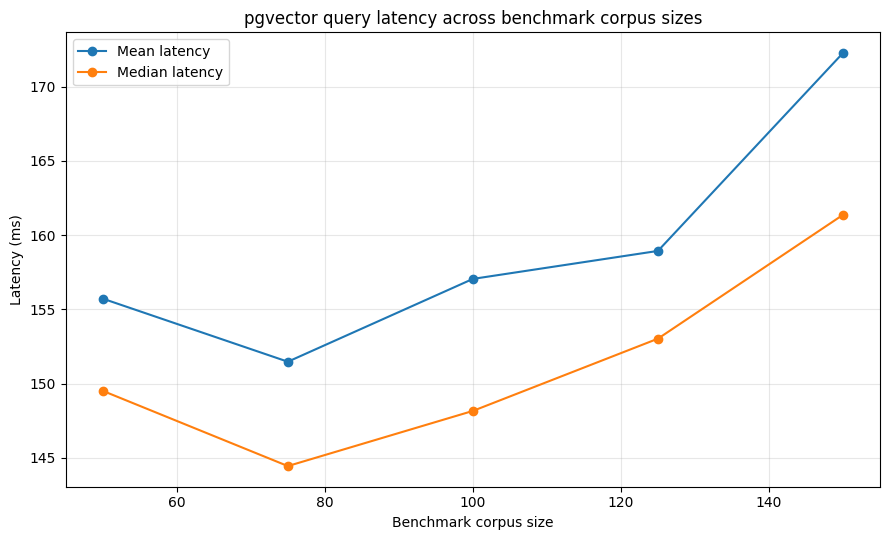

Saved figure to: C:\Users\user\Documents\thesis\reports\tables\pgvector_scaling\pgvector_scaling_latency_plot.png


In [89]:
# Cell 24 - Create the pgvector scaling figure

import matplotlib.pyplot as plt

latency_plot_path = OUTPUT_DIR / "pgvector_scaling_latency_plot.png"

plt.figure(figsize=(9, 5.5))
plt.plot(
    thesis_scaling_table_df["corpus_size"],
    thesis_scaling_table_df["mean_latency_ms"],
    marker="o",
    label="Mean latency",
)
plt.plot(
    thesis_scaling_table_df["corpus_size"],
    thesis_scaling_table_df["median_latency_ms"],
    marker="o",
    label="Median latency",
)

plt.xlabel("Benchmark corpus size")
plt.ylabel("Latency (ms)")
plt.title("pgvector query latency across benchmark corpus sizes")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(latency_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure to:", latency_plot_path)

### Results interpretation

The results should be interpreted in two layers.

**Operational layer**  
The 50-course corpus represents the real proof-of-concept scale. This is the main practical evaluation point for the thesis.

**Scaling layer**  
The larger benchmark corpora at 75, 100, 125, and 150 rows are used to observe how pgvector retrieval behaves as corpus size increases.

Because the larger corpora were created by controlled replication, they support **row-count scaling analysis**, not semantic-quality analysis.

For this reason, the most important interpretation focus is:

- whether latency remains practically usable
- whether retrieval behaviour stays stable
- whether larger corpora introduce problematic slowdown

In [90]:
# Cell 25 - Generate concise interpretation values for reporting

row_50 = thesis_scaling_table_df.loc[thesis_scaling_table_df["corpus_size"] == 50].iloc[0]
row_150 = thesis_scaling_table_df.loc[thesis_scaling_table_df["corpus_size"] == 150].iloc[0]

highest_variance_row = thesis_scaling_table_df.loc[
    thesis_scaling_table_df["std_latency_ms"].idxmax()
]

print("50-course baseline:")
print(f"  Mean latency   : {row_50['mean_latency_ms']:.4f} ms")
print(f"  Median latency : {row_50['median_latency_ms']:.4f} ms")
print()
print("150-row scaling point:")
print(f"  Mean latency   : {row_150['mean_latency_ms']:.4f} ms")
print(f"  Median latency : {row_150['median_latency_ms']:.4f} ms")
print()
print("Change from 50 to 150:")
print(f"  Mean delta     : {row_150['delta_mean_vs_50_ms']:.4f} ms")
print(f"  Mean ratio     : {row_150['ratio_mean_vs_50']:.4f}x")
print(f"  Median delta   : {row_150['delta_median_vs_50_ms']:.4f} ms")
print(f"  Median ratio   : {row_150['ratio_median_vs_50']:.4f}x")
print()
print("Highest variance corpus size:")
print(f"  Corpus size    : {int(highest_variance_row['corpus_size'])}")
print(f"  Std latency    : {highest_variance_row['std_latency_ms']:.4f} ms")
print(f"  Max latency    : {highest_variance_row['max_latency_ms']:.4f} ms")

50-course baseline:
  Mean latency   : 155.7280 ms
  Median latency : 149.5203 ms

150-row scaling point:
  Mean latency   : 172.2672 ms
  Median latency : 161.3715 ms

Change from 50 to 150:
  Mean delta     : 16.5392 ms
  Mean ratio     : 1.1062x
  Median delta   : 11.8512 ms
  Median ratio   : 1.0793x

Highest variance corpus size:
  Corpus size    : 150
  Std latency    : 40.5503 ms
  Max latency    : 329.5631 ms


### Answer to research question 2

**How does performance scale with corpus size in a pgvector implementation?**

Based on this benchmark, pgvector retrieval remained **operationally feasible** across the tested range from **50 rows to 150 rows**.

At the intended proof-of-concept scale of **50 courses** corresponding to the real 50-row corpus, query latency remained practical. When the benchmark corpus was expanded beyond that point, latency stayed within a similar operational range, although some larger benchmark sizes showed higher variance and occasional slower runs.

The results therefore support the conclusion that, for the tested institutional proof-of-concept scale, pgvector retrieval is feasible and does not show problematic degradation.

### Limitations

This benchmark has three important limitations.

1. **Replicated rows above 50**  
   Corpus sizes above 50 were created by replicating the original embeddings. This supports row-count scaling analysis, but not semantic-diversity analysis.

2. **Cloud-database timing noise**  
   The benchmark was run in a cloud PostgreSQL environment, so measured latency also reflects connection overhead, shared infrastructure effects, and transient service variability.

3. **Retrieval-only timing**  
   The benchmark evaluates pgvector retrieval latency, not full end-to-end application latency. A production system would also include UI, API, and application-processing overhead.

Despite these limitations, the notebook is sufficient for the thesis because it directly answers the pgvector implementation question at the intended proof-of-concept scale.

### Final conclusion of Notebook 05

Notebook 06 evaluated the final selected overlap-detection configuration in a **PostgreSQL + pgvector** implementation.

The notebook demonstrated two main findings:

1. **50-course operational evaluation**  
   At the real proof-of-concept scale of 50 courses, represented by the 50-row benchmark corpus, pgvector retrieval operated at practical latency levels.

2. **Scaling evaluation from 50 rows to 150 rows**  
   Across the tested benchmark sizes, retrieval remained stable and operationally feasible. Larger benchmark corpora introduced some latency variation, but no problematic degradation was observed.

Overall, the notebook supports the thesis conclusion that the selected configuration is not only semantically effective, but also operationally feasible in a pgvector-based implementation for the intended institutional proof-of-concept scope.

In [91]:
# Cell 26 - Summarize final notebook outputs

final_notebook_06_summary = {
    "selected_model": FINAL_MODEL_NAME,
    "selected_text_variant": FINAL_TEXT_VARIANT,
    "selected_similarity_metric": FINAL_SIMILARITY_METRIC,
    "selected_selection_rule": FINAL_SELECTION_RULE,
    "selected_locked_threshold": round(FINAL_LOCKED_THRESHOLD, 10),
    "benchmark_corpus_sizes": sorted(thesis_scaling_table_df["corpus_size"].tolist()),
    "baseline_50_mean_latency_ms": round(float(row_50["mean_latency_ms"]), 4),
    "baseline_50_median_latency_ms": round(float(row_50["median_latency_ms"]), 4),
    "largest_150_mean_latency_ms": round(float(row_150["mean_latency_ms"]), 4),
    "largest_150_median_latency_ms": round(float(row_150["median_latency_ms"]), 4),
    "raw_results_path": str(raw_results_path),
    "summary_by_corpus_path": str(summary_by_corpus_path),
    "summary_by_query_path": str(summary_by_query_path),
    "thesis_table_path": str(thesis_scaling_table_path),
    "latency_plot_path": str(latency_plot_path),
}

for key, value in final_notebook_06_summary.items():
    print(f"{key}: {value}")

selected_model: openai_text-embedding-3-large
selected_text_variant: enriched
selected_similarity_metric: cosine
selected_selection_rule: max_f1
selected_locked_threshold: 0.6737841964
benchmark_corpus_sizes: [50, 75, 100, 125, 150]
baseline_50_mean_latency_ms: 155.728
baseline_50_median_latency_ms: 149.5203
largest_150_mean_latency_ms: 172.2672
largest_150_median_latency_ms: 161.3715
raw_results_path: C:\Users\user\Documents\thesis\reports\tables\pgvector_scaling\pgvector_scaling_raw_results.csv
summary_by_corpus_path: C:\Users\user\Documents\thesis\reports\tables\pgvector_scaling\pgvector_scaling_summary_by_corpus.csv
summary_by_query_path: C:\Users\user\Documents\thesis\reports\tables\pgvector_scaling\pgvector_scaling_summary_by_query.csv
thesis_table_path: C:\Users\user\Documents\thesis\reports\tables\pgvector_scaling\pgvector_scaling_thesis_table.csv
latency_plot_path: C:\Users\user\Documents\thesis\reports\tables\pgvector_scaling\pgvector_scaling_latency_plot.png
